# FASE 6: Modelamiento Predictivo y Validación Preliminar

**Objetivo:** Entrenar un modelo base de clasificación multiclase sobre el dataset `df_master` para predecir el riesgo de diabetes según los criterios de la ADA.

**Target (`DIABETES_RISK`):**
- **Clase 0** – Sin riesgo (43.6%)
- **Clase 1** – Prediabetes (19.5%)
- **Clase 2** – Diabetes (9.0%)

**Nota:** Existe desbalance de clases, por lo que usamos estratificación, pesos balanceados y métricas adecuadas (F1, Precision, Recall por clase).

---

### Flujo del Notebook
1. Carga y exploración rápida del dataset
2. Separación X / y y partición Train / Test estratificada
3. Preprocesamiento con `Pipeline` + `ColumnTransformer`
4. Entrenamiento del modelo base (Random Forest)
5. Predicción dual: clase + probabilidades
6. Evaluación: Matriz de Confusión + Classification Report

---
## 1. Imports y Carga de Datos

In [1]:
# Cargar extensión de Kedro para acceder al catálogo
%load_ext kedro.ipython

[06/15/26 18:56:11] INFO     Using                                                                  ]8;id=39066;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=52590;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packa                
                             ges\kedro\framework\project\rich_logging.yml' as logging                              
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=431192;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=47160;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=422444;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=623304;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=596462;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=813376;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\alarc\OneDrive\Escritorio\Proyecto_Nhanes_Kedro\proyecto_nhan                
                             es_kedro.                                                                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/15/26 18:56:14] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=811365;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=828067;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[06/15/26 18:56:15] INFO     Kedro project Proyecto NHANES Kedro                                    ]8;id=781230;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=860694;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=405340;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=727010;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42

print('Imports cargados correctamente.')

Imports cargados correctamente.


In [3]:
# Cargar el dataset final desde el catálogo de Kedro
df = catalog.load('df_master')
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()[:20]}...')  # primeras 20
df.head()

[06/15/26 18:56:30] INFO     Loading data from df_master (ParquetDataset)...                   ]8;id=68370;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=879388;file://c:\Users\alarc\AppData\Local\Programs\Python\Python312\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

Shape: (6045, 709)
Columnas: ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMQMILIZ', 'DMDBORN4', 'DMDCITZN', 'DMDEDUC2', 'DMDMARTL', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAINTRP', 'MIALANG', 'MIAINTRP', 'AIALANGA', 'DMDHHSIZ']...


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMQMILIZ,DMDBORN4,DMDCITZN,DMDEDUC2,...,BP_SYSTOLIC_AVG,BP_DIASTOLIC_AVG,MAP,BMI_CATEGORY,ACR,AGE_GROUP,CARB_FIBER_RATIO,NON_HDL_CHOL,eGFR,DIABETES_RISK
0,93705.0,2.0,66.0,4.0,4.0,2.0,2.0,1.0,1.0,2.0,...,167.000000,66.000000,99.666667,3,13.333333,3,18.744048,97.0,64.881568,1
1,93706.0,1.0,18.0,5.0,6.0,2.0,2.0,1.0,1.0,NaN,...,129.000000,71.000000,90.333333,1,57.391304,0,12.650704,101.0,129.751359,0
2,93707.0,1.0,13.0,5.0,7.0,2.0,NaN,1.0,1.0,NaN,...,136.000000,71.333333,92.888889,0,19.904306,0,17.261468,121.0,148.051580,0
3,93708.0,2.0,66.0,5.0,6.0,2.0,2.0,2.0,1.0,1.0,...,146.333333,79.666667,101.888889,1,19.361702,3,7.452410,121.0,96.047648,1
4,93709.0,2.0,75.0,4.0,4.0,1.0,2.0,1.0,1.0,4.0,...,119.000000,79.333333,92.555556,4,12.279070,3,NaN,111.0,39.364993,1


Distribución del Target:
  Clase 0 (Sin Riesgo): 3,659 registros (60.5%)
  Clase 1 (Prediabetes): 1,635 registros (27.0%)
  Clase 2 (Diabetes): 751 registros (12.4%)


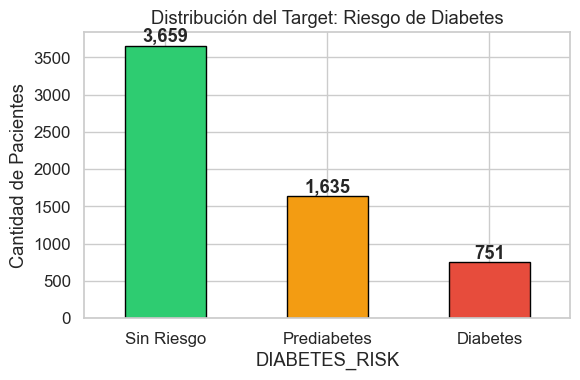

In [4]:
# Distribución del target
target_col = 'DIABETES_RISK'
labels_map = {0: 'Sin Riesgo', 1: 'Prediabetes', 2: 'Diabetes'}

print('Distribución del Target:')
dist = df[target_col].value_counts().sort_index()
for val, count in dist.items():
    pct = count / len(df) * 100
    print(f'  Clase {val} ({labels_map[val]}): {count:,} registros ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
dist.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_xticklabels([labels_map[i] for i in dist.index], rotation=0)
ax.set_ylabel('Cantidad de Pacientes')
ax.set_title('Distribución del Target: Riesgo de Diabetes')
for i, (val, count) in enumerate(dist.items()):
    ax.text(i, count + 50, f'{count:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Separación de Features (X) y Target (y)

In [5]:
# Columnas a excluir del entrenamiento:
# - SEQN: es un identificador, no un feature
# - DIABETES_RISK: es el target
exclude_cols = ['SEQN', target_col]

feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nTipos de datos en X:')
print(X.dtypes.value_counts())

Features (X): (6045, 707)
Target  (y): (6045,)

Tipos de datos en X:
float64    628
object      77
Int64        2
Name: count, dtype: int64


In [6]:
# Identificar columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Columnas numéricas: {len(numeric_cols)}')
print(f'Columnas categóricas: {len(categorical_cols)}')

if categorical_cols:
    print(f'  -> Categóricas detectadas: {categorical_cols[:10]}')

Columnas numéricas: 630
Columnas categóricas: 77
  -> Categóricas detectadas: ['BPAOARM', 'LUAPNME', 'LUATECH', 'OHX02CTC', 'OHX03CTC', 'OHX04CTC', 'OHX05CTC', 'OHX06CTC', 'OHX07CTC', 'OHX08CTC']


---
## 3. Train / Test Split Estratificado

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y  # Mantiene la proporción de clases en ambos sets
)

print(f'Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.1f}%)')

print('\nDistribución del target en Train:')
for val, count in y_train.value_counts().sort_index().items():
    print(f'  Clase {val}: {count:,} ({count/len(y_train)*100:.1f}%)')

print('\nDistribución del target en Test:')
for val, count in y_test.value_counts().sort_index().items():
    print(f'  Clase {val}: {count:,} ({count/len(y_test)*100:.1f}%)')

Train: 4836 registros (80.0%)
Test:  1209 registros (20.0%)

Distribución del target en Train:
  Clase 0: 2,927 (60.5%)
  Clase 1: 1,308 (27.0%)
  Clase 2: 601 (12.4%)

Distribución del target en Test:
  Clase 0: 732 (60.5%)
  Clase 1: 327 (27.0%)
  Clase 2: 150 (12.4%)


---
## 4. Pipeline de Preprocesamiento + Modelo

Usamos un `Pipeline` de scikit-learn para encapsular:
1. **Imputación** de valores nulos con la mediana (numéricos) o la moda (categóricos)
2. **Escalado** con `StandardScaler` para las variables numéricas
3. **Codificación ordinal** para categóricas (si las hay)
4. **RandomForestClassifier** con `class_weight='balanced'` para compensar el desbalance

Todo dentro del pipeline para **evitar data leakage** (el scaler y el imputer se ajustan solo con datos de Train).

In [8]:
# --- Preprocesador por tipo de columna ---

# Transformador para columnas numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformador para columnas categóricas (si existen)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer: aplica cada transformador a su grupo de columnas
transformers_list = [('num', numeric_transformer, numeric_cols)]
if categorical_cols:
    transformers_list.append(('cat', categorical_transformer, categorical_cols))

preprocessor = ColumnTransformer(
    transformers=transformers_list,
    remainder='drop'  # Columnas no listadas se descartan
)

print('Preprocesador configurado:')
print(f'  Numéricas: {len(numeric_cols)} cols -> Imputer(median) + StandardScaler')
if categorical_cols:
    print(f'  Categóricas: {len(categorical_cols)} cols -> Imputer(mode) + OrdinalEncoder')

Preprocesador configurado:
  Numéricas: 630 cols -> Imputer(median) + StandardScaler
  Categóricas: 77 cols -> Imputer(mode) + OrdinalEncoder


In [9]:
# --- Pipeline completo: Preprocesamiento + Modelo ---

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',   # Compensa el desbalance de clases
        random_state=RANDOM_STATE,
        n_jobs=-1                  # Usar todos los cores
    ))
])

print('Pipeline completo definido:')
print(model_pipeline)

Pipeline completo definido:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RIAGENDR', 'RIDAGEYR',
                                                   'RIDRETH1', 'RIDRETH3',
                                                   'RIDEXMON', 'DMQMILIZ',
                                                   'DMDBORN4', 'DMDCITZN',
                                                   'DMDEDUC2', 'DMDMARTL',
                                                   'SIALANG', 'SIAPROXY',
                                                   'SIAINTRP', 'FIALANG',
              

---
## 5. Entrenamiento del Modelo Base

In [10]:
%%time
# Entrenar el pipeline completo (preprocesamiento + modelo)
model_pipeline.fit(X_train, y_train)
print('Modelo entrenado exitosamente.')

Modelo entrenado exitosamente.
CPU times: total: 19.4 s
Wall time: 2.41 s


In [11]:
# Validación cruzada estratificada (5-Fold) sobre el set de Train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    model_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=['f1_macro', 'accuracy'],
    n_jobs=-1,
    return_train_score=False
)

print('=== Validación Cruzada (5-Fold Estratificado) ===')
print(f'F1 Macro:  {cv_results["test_f1_macro"].mean():.4f} ± {cv_results["test_f1_macro"].std():.4f}')
print(f'Accuracy:  {cv_results["test_accuracy"].mean():.4f} ± {cv_results["test_accuracy"].std():.4f}')
print(f'\nDetalle por fold (F1 Macro): {np.round(cv_results["test_f1_macro"], 4)}')

=== Validación Cruzada (5-Fold Estratificado) ===
F1 Macro:  0.6547 ± 0.0095
Accuracy:  0.7179 ± 0.0080

Detalle por fold (F1 Macro): [0.6574 0.6658 0.6621 0.6484 0.6397]


---
## 6. Predicción Dual: Clase + Probabilidades

In [12]:
# Predicción sobre el set de Test
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)

print(f'Predicciones generadas: {len(y_pred)} registros')
print(f'Probabilidades shape: {y_proba.shape}  (filas x clases)')

Predicciones generadas: 1209 registros
Probabilidades shape: (1209, 3)  (filas x clases)


In [13]:
# === Ejemplo de Predicción para un Paciente del Set de Test ===

# Tomar 5 pacientes aleatorios del test set
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(X_test), size=5, replace=False)

print('=' * 75)
print('EJEMPLO: PREDICCIÓN DUAL (Clase + Porcentaje de Riesgo)')
print('=' * 75)

for i, idx in enumerate(sample_indices):
    clase_real = y_test.iloc[idx]
    clase_pred = y_pred[idx]
    probs = y_proba[idx]
    
    print(f'\n--- Paciente {i+1} ---')
    print(f'  Clase Real:      {int(clase_real)} ({labels_map[int(clase_real)]})')
    print(f'  Clase Predicha:  {int(clase_pred)} ({labels_map[int(clase_pred)]})')
    print(f'  Probabilidades:')
    for cls_idx, prob in enumerate(probs):
        marker = ' ◄' if cls_idx == int(clase_pred) else ''
        print(f'    Clase {cls_idx} ({labels_map[cls_idx]:>12}): {prob*100:6.2f}%{marker}')
    
    acierto = '✅ CORRECTO' if clase_real == clase_pred else '❌ INCORRECTO'
    print(f'  Resultado: {acierto}')

print('\n' + '=' * 75)

EJEMPLO: PREDICCIÓN DUAL (Clase + Porcentaje de Riesgo)

--- Paciente 1 ---
  Clase Real:      1 (Prediabetes)
  Clase Predicha:  1 (Prediabetes)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  34.52%
    Clase 1 ( Prediabetes):  42.38% ◄
    Clase 2 (    Diabetes):  23.10%
  Resultado: ✅ CORRECTO

--- Paciente 2 ---
  Clase Real:      1 (Prediabetes)
  Clase Predicha:  0 (Sin Riesgo)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  47.15% ◄
    Clase 1 ( Prediabetes):  44.43%
    Clase 2 (    Diabetes):   8.42%
  Resultado: ❌ INCORRECTO

--- Paciente 3 ---
  Clase Real:      0 (Sin Riesgo)
  Clase Predicha:  0 (Sin Riesgo)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  80.43% ◄
    Clase 1 ( Prediabetes):  17.33%
    Clase 2 (    Diabetes):   2.24%
  Resultado: ✅ CORRECTO

--- Paciente 4 ---
  Clase Real:      0 (Sin Riesgo)
  Clase Predicha:  1 (Prediabetes)
  Probabilidades:
    Clase 0 (  Sin Riesgo):  37.81%
    Clase 1 ( Prediabetes):  42.20% ◄
    Clase 2 (    Diabetes):  19.99%
  

### Interpretación de las Probabilidades

Cuando el modelo evalúa un paciente, `predict_proba()` retorna un vector con 3 valores que suman 1.0, representando la **confianza** del modelo en cada clase:

- **Ejemplo**: `[0.15, 0.60, 0.25]` → El modelo cree con un 60% de certeza que el paciente tiene **Prediabetes**, un 25% de que tiene **Diabetes** y solo un 15% de que no tiene riesgo.
- La **clase predicha** es siempre la de mayor probabilidad (en este caso, clase 1 = Prediabetes).
- Un paciente con probabilidades `[0.33, 0.34, 0.33]` (muy distribuidas) indica **alta incertidumbre** del modelo, lo cual es clínicamente útil para derivar a exámenes adicionales.

---
## 7. Evaluación del Modelo

In [14]:
# --- Classification Report ---
target_names = ['Sin Riesgo (0)', 'Prediabetes (1)', 'Diabetes (2)']

print('=' * 65)
print('CLASSIFICATION REPORT')
print('=' * 65)
report = classification_report(
    y_test, y_pred,
    target_names=target_names,
    digits=3
)
print(report)

# F1 Macro y Weighted (resumen global)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f'F1 Macro (métrica principal):   {f1_macro:.4f}')
print(f'F1 Weighted:                    {f1_weighted:.4f}')

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Sin Riesgo (0)      0.791     0.885     0.836       732
Prediabetes (1)      0.571     0.440     0.497       327
   Diabetes (2)      0.761     0.700     0.729       150

       accuracy                          0.742      1209
      macro avg      0.708     0.675     0.687      1209
   weighted avg      0.728     0.742     0.731      1209

F1 Macro (métrica principal):   0.6874
F1 Weighted:                    0.7309


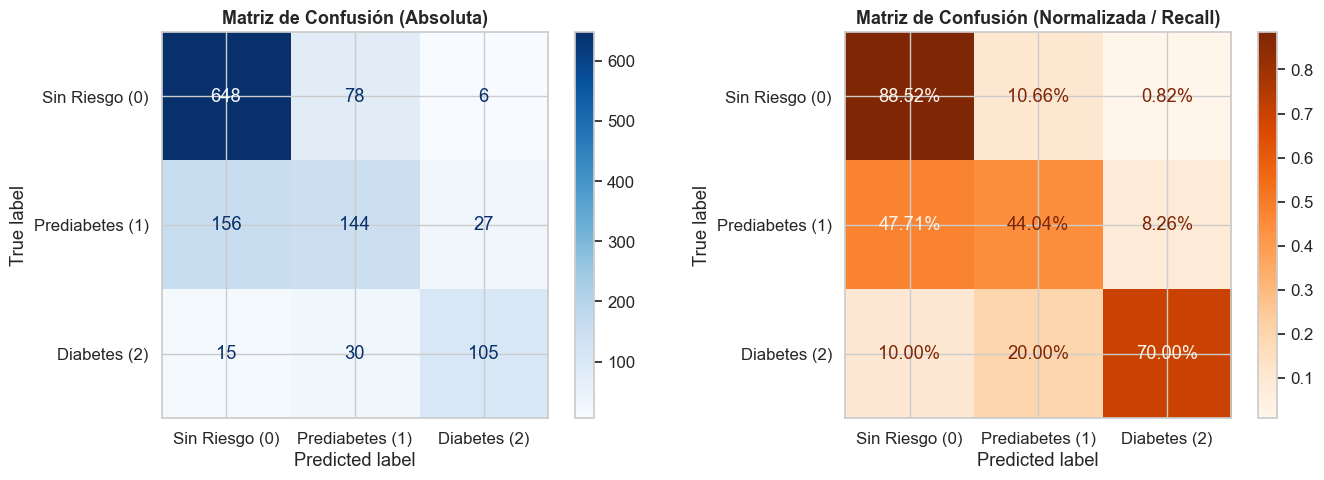


Análisis de la Matriz de Confusión:
  Sin Riesgo (0): 648/732 correctos (Recall = 88.5%)
  Prediabetes (1): 144/327 correctos (Recall = 44.0%)
  Diabetes (2): 105/150 correctos (Recall = 70.0%)


In [15]:
# --- Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluta
disp1 = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión (Absoluta)', fontsize=13, fontweight='bold')

# Normalizada por fila (Recall por clase)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(cm_norm, display_labels=target_names)
disp2.plot(ax=axes[1], cmap='Oranges', values_format='.2%')
axes[1].set_title('Matriz de Confusión (Normalizada / Recall)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis por clase
print('\nAnálisis de la Matriz de Confusión:')
for i, name in enumerate(target_names):
    tp = cm[i, i]
    total_real = cm[i, :].sum()
    recall_i = tp / total_real if total_real > 0 else 0
    print(f'  {name}: {tp}/{total_real} correctos (Recall = {recall_i:.1%})')

---
## 8. Feature Importance (Top 20)

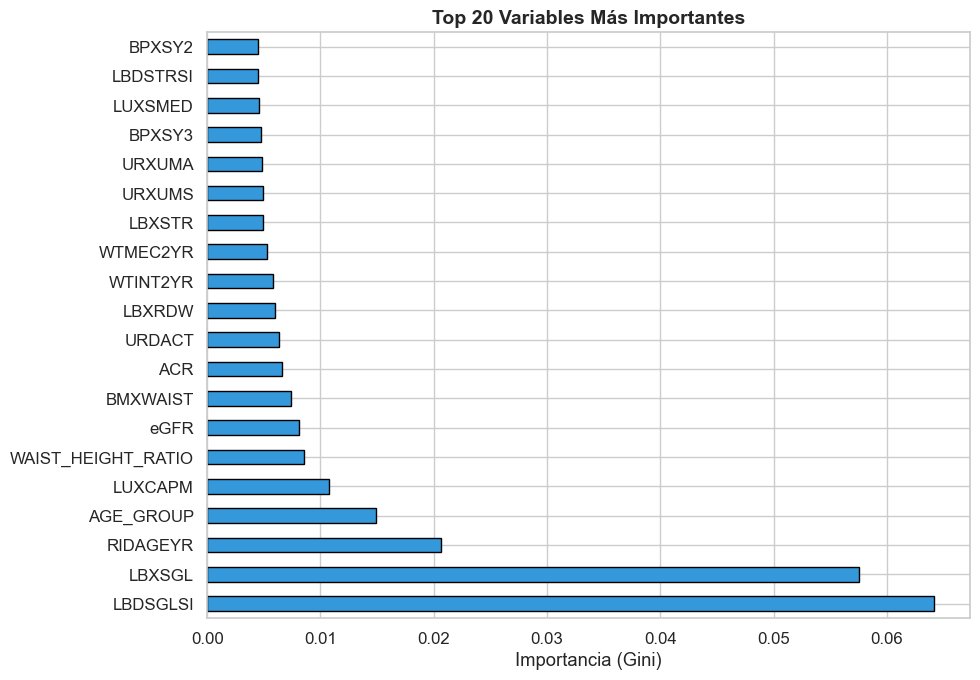


Top 20 features y su importancia:
  LBDSGLSI................................ 0.0642
  LBXSGL.................................. 0.0575
  RIDAGEYR................................ 0.0206
  AGE_GROUP............................... 0.0149
  LUXCAPM................................. 0.0108
  WAIST_HEIGHT_RATIO...................... 0.0086
  eGFR.................................... 0.0081
  BMXWAIST................................ 0.0074
  ACR..................................... 0.0066
  URDACT.................................. 0.0064
  LBXRDW.................................. 0.0060
  WTINT2YR................................ 0.0058
  WTMEC2YR................................ 0.0053
  LBXSTR.................................. 0.0050
  URXUMS.................................. 0.0049
  URXUMA.................................. 0.0049
  BPXSY3.................................. 0.0048
  LUXSMED................................. 0.0046
  LBDSTRSI................................ 0.0045
  BPXSY2.......

In [16]:
# Extraer importancias del RandomForest
rf_model = model_pipeline.named_steps['classifier']

# Reconstruir los nombres de las features transformadas
feature_names_out = numeric_cols.copy()
if categorical_cols:
    feature_names_out += categorical_cols

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names_out
).sort_values(ascending=False)

# Top 20
top_n = 20
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
top_features.sort_values().plot(
    kind='barh', color='#3498db', edgecolor='black', ax=ax
)
ax.set_xlabel('Importancia (Gini)')
ax.set_title(f'Top {top_n} Variables Más Importantes', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f'\nTop {top_n} features y su importancia:')
for feat, imp in top_features.items():
    print(f'  {feat:.<40} {imp:.4f}')

---
## 9. Resumen y Conclusiones Preliminares

### ¿Qué hicimos?
- Entrenamos un **Random Forest Classifier** como modelo base, usando un pipeline completo de scikit-learn que encapsula imputación, escalado y clasificación.
- Usamos `class_weight='balanced'` para compensar el desbalance de clases.
- Validamos con **Cross-Validation estratificado** (5-Fold) y evaluamos en un **test set separado**.

### Métricas Clave
- **F1 Macro**: Métrica principal. Promedia el F1 de cada clase con igual peso, penalizando al modelo si falla en la clase minoritaria (Diabetes).
- **Recall por clase**: Especialmente importante para **Clase 2 (Diabetes)**, donde fallar en detectar un caso real tiene alto costo clínico.

### Próximos Pasos
- Optimización hiperparamétrica con `RandomizedSearchCV` o `Optuna`.
- Probar otros algoritmos (XGBoost, LightGBM, etc.).
- Análisis de errores: ¿qué pacientes confunde el modelo y por qué?
- Evaluar curvas ROC multiclase y Precision-Recall por clase.